In [ ]:
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# import data
file_path = '2023_final_data_set.csv'
data = pd.read_csv(file_path)

# print first few rows of the data
print(data.head())

   Year     Sector     Subsector                            Organization  \
0  2023  Municipal  Municipality  The Corporation of the City of Markham   
1  2023  Municipal  Municipality  The Corporation of the City of Markham   
2  2023  Municipal  Municipality  The Corporation of the City of Markham   
3  2023  Municipal  Municipality  The Corporation of the City of Markham   
4  2023  Municipal  Municipality  The Corporation of the City of Markham   

      Property Name Primary Property Type - Self Selected  \
0  Fire Station #91                          Fire Station   
1  Fire Station #92                          Fire Station   
2  Fire Station #93                          Fire Station   
3  Fire Station #94                          Fire Station   
4  Fire Station #95                          Fire Station   

   Portfolio Manager Property ID Portfolio Manager Parent Property ID  \
0                        3634451  Not Applicable: Standalone Property   
1                        36344

In [123]:
# convert site energy use to numeric
data["Weather Normalized Site Energy Use (GJ)"] = pd.to_numeric(data["Weather Normalized Site Energy Use (GJ)"], errors="coerce")

# drop missing values in key columns
data = data.dropna(subset=["Sector", "Subsector", "Weather Normalized Site Energy Use (GJ)"])

# drop rows that are classified as "Non-BPS"
data = data[data["Sector"] != "Non-BPS"]

# group by subsector and sum site energy use
subsec_totals = data.groupby(["Sector", "Subsector"])["Weather Normalized Site Energy Use (GJ)"].sum().reset_index()
subsec_totals = subsec_totals.sort_values(by="Weather Normalized Site Energy Use (GJ)", ascending=False)
subsec_totals["Site Energy Use (Million GJ)"] = round(subsec_totals["Weather Normalized Site Energy Use (GJ)"] / 1e6, 4)
print(subsec_totals)

            Sector      Subsector  Weather Normalized Site Energy Use (GJ)  \
0        Municipal   Municipality                               13363750.4   
4  Public Hospital  Acute/Chronic                                4654612.0   
2  Post-Secondary      University                                1168178.6   
1  Post-Secondary         College                                1064848.4   
3  Public Hospital          Acute                                 552231.9   
5  Public Hospital        Chronic                                 233856.5   

   Site Energy Use (Million GJ)  
0                       13.3638  
4                        4.6546  
2                        1.1682  
1                        1.0648  
3                        0.5522  
5                        0.2339  


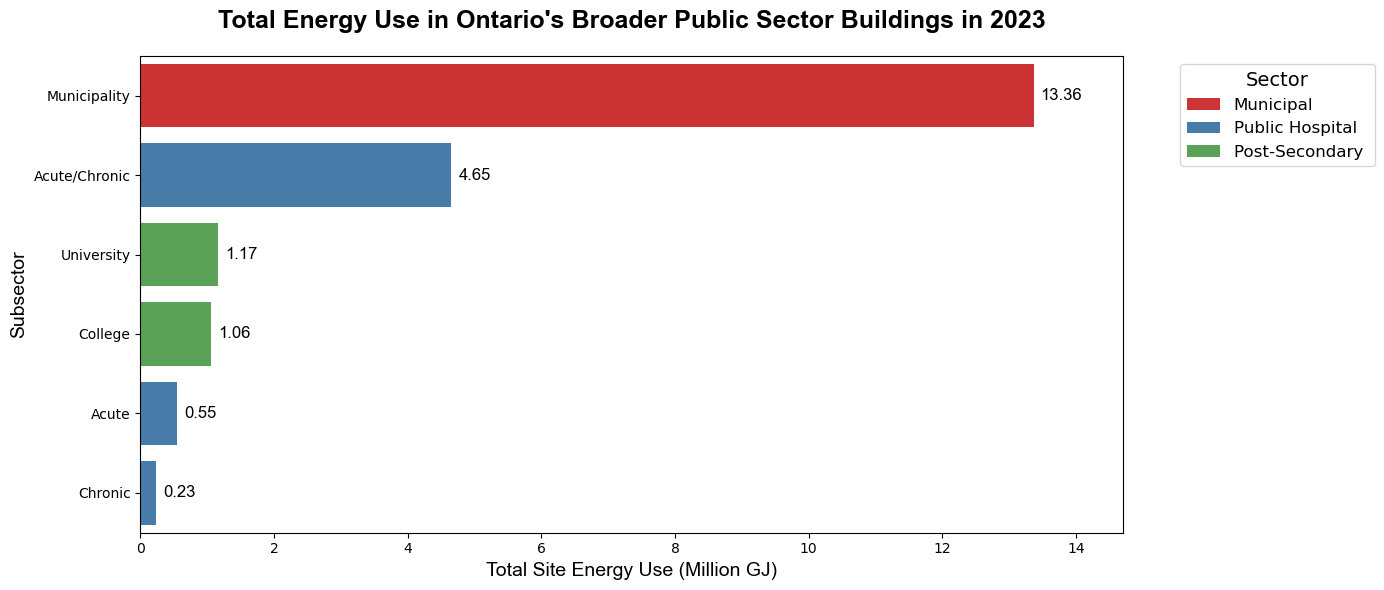

In [125]:
# create bar plot
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=subsec_totals,
    y="Subsector",
    x="Site Energy Use (Million GJ)",
    hue="Sector",
    palette="Set1" # color palette for bars
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, 
                 fmt="%.2f", 
                 label_type="edge", 
                 fontsize=12, fontname="Arial",
                 padding=5)

# customize axes, title and legend
plt.xlabel("Total Site Energy Use (Million GJ)",
           fontsize=14, fontname="Arial")
plt.ylabel("Subsector",
           fontsize=14, fontname="Arial")
plt.title("Total Energy Use in Ontario's Broader Public Sector Buildings in 2023",
            fontsize=18, fontweight="bold", fontname="Arial", pad=20)
plt.legend(title="Sector", bbox_to_anchor=(1.05, 1), loc="upper left",
           fontsize=12, title_fontsize=14)
plt.tight_layout()

# extend x-axis limits for better label visibility
plt.xlim(0, subsec_totals["Site Energy Use (Million GJ)"].max() * 1.1)
plt.show()
